In [8]:
import torch
import torch.nn as nn

from torch.utils.data  import DataLoader
from torchvision.datasets import MNIST
import torch.nn.functional as F
import torchvision.utils
from torch.utils.data import TensorDataset

from tqdm import tqdm
import numpy as np
import random
#import matplotlib
#matplotlib.use('qtagg')
#%matplotlib ipympl
import matplotlib.pyplot as plt

In [12]:
# load the custom MNIST provided for this assessment
# it is a .pt file containing tensors, not a torchvision MNIST dataset
import os

print("file size:", os.path.getsize('mnist_custom.pt'), "bytes (expected 112562040)")

d = torch.load('mnist_custom.pt', map_location='cpu', weights_only=False)

for k, v in d.items():
    print(k, tuple(v.shape), v.dtype, "min", float(v.min()), "max", float(v.max()))

bs_train = 1000
bs_test  = 1000

train_dataset = TensorDataset(d['train_images'], d['train_labels'])
test_dataset  = TensorDataset(d['test_images'],  d['test_labels'])

train_dataloader = DataLoader(train_dataset, batch_size=bs_train, shuffle=True,  num_workers=0)
test_dataloader  = DataLoader(test_dataset,  batch_size=bs_test,  shuffle=False, num_workers=0)

# check one batch
x, y = next(iter(train_dataloader))
print("batch:", x.shape, y.shape)

file size: 112562040 bytes (expected 112562040)
train_images (60000, 1, 20, 20) torch.float32 min 0.0 max 1.0
train_labels (60000,) torch.int64 min 0.0 max 9.0
test_images (10000, 1, 20, 20) torch.float32 min 0.0 max 1.0
test_labels (10000,) torch.int64 min 0.0 max 9.0
batch: torch.Size([1000, 1, 20, 20]) torch.Size([1000])


In [13]:
# Create an encoder to encode the 1x20x20 images into a latent vector of dimension z_dim
class cEncoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cEncoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        # Define the encoder layers
        self.encoder_backbone = nn.Sequential(
            # Layer 1: 1x20x20 -> 16x10x10
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 2: 16x10x10 -> 32x5x5
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 3: 32x5x5 -> 64x3x3
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 5: 64x3x3 -> 256x1x1  (kernel 3 instead of 4, the feature map
            # is 3x3 here rather than 4x4 because the input is 20x20 not 28x28)
            nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Flatten and project to z_dim
            nn.Flatten(),  # 256*1*1 = 256
        )
        self.encoder_head = nn.Sequential(
           nn.Linear(256+num_classes, 2*z_dim)
        )

    def forward(self, x, cond):
        # x shape: (batch_size, 1, 20, 20)
        x = self.encoder_backbone(x)
        x = torch.cat([x, cond], dim=1)
        x = self.encoder_head(x)
        mu,logvar = torch.chunk(x, 2, dim=1)
        return mu,logvar

In [14]:
class cDecoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cDecoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        self.decoder_input =  nn.Sequential(
            # Project latent vector to a feature map
            nn.Linear(z_dim + num_classes, 256),
            nn.ReLU(),
        )
        self.decoder_backbone = nn.Sequential(
            nn.Unflatten(1, (256, 1, 1)),  # Reshape to (256, 1, 1)
            # Layer 1: 256x1x1 -> 64x3x3  (mirrors the encoder's 3x3 feature map)
            nn.ConvTranspose2d(256, 64, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Layer 3: 64x3x3 -> 32x5x5
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),
            # Layer 4: 32x5x5 -> 16x10x10
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # Layer 5: 16x10x10 -> 1x20x20
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0, 1] for pixel values
        )

    def forward(self, z, cond):
        z = torch.cat([z, cond], dim=1)
        z = self.decoder_input(z)
        x_hat  = self.decoder_backbone(z)
        # z shape: (batch_size, z_dim)
        return x_hat

In [15]:
class cVAE(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cVAE, self).__init__()
        self.encoder = cEncoder(z_dim, num_classes)
        self.decoder = cDecoder(z_dim, num_classes)
        self.z_dim =  z_dim
        self.num_classes = num_classes
    
    def encode(self,x,cond):
        return self.encoder(x,cond)

    def decode(self,z,cond):
        return self.decoder(z,cond)
    
    def forward(self, x, cond):
        mu,logvar = self.encoder(x, cond)
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)
        z = mu + eps * sigma
        x_recon = self.decoder(z, cond)
        return x_recon,mu,logvar

In [16]:
# parameters
z_dim = 7   # the brief specifies 7 latent dimensions (the tutorial used 8)

model = cVAE(z_dim, num_classes = 10)
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
model = model.to(device)

print("\n---total number of parameters:")
print(sum(p.numel() for p in model.parameters()))

# check the shapes line up with the 20x20 input
x, y = next(iter(train_dataloader))
x = x[:4].to(device)
cond = F.one_hot(y[:4], num_classes=10).float().to(device)
x_hat, mu, logvar = model(x, cond)
print("input :", tuple(x.shape))
print("output:", tuple(x_hat.shape))
print("mu    :", tuple(mu.shape))


---total number of parameters:
350107
input : (4, 1, 20, 20)
output: (4, 1, 20, 20)
mu    : (4, 7)


In [17]:
def compute_loss(x, x_hat, mu, logvar, beta=0.1):
    """
    Compute the reconstruction loss for the autoencoder.
    """
    # Reconstruction loss (MSE)
    recon_loss = 100*F.mse_loss(x_hat, x, reduction='mean')

    # For standard autoencoder, KL divergence is 0
    if beta == 0:
        kl_loss = 0.0
    else:
        kl_loss = torch.mean(-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))

    # Total loss
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [20]:
import torch.optim as optim
from torchvision.utils import make_grid

def get_batch(batch, device,f_train=True,num_classes=10):
    # f_train to select if this is a batch for training or testing
    # not used here, but will be useful later
    x  = batch[0].to(device)
    cond  = batch[1].to(device)
    cond = F.one_hot(cond, num_classes=num_classes).float()
    return x,cond

def training_loop(model,train_dataloader,test_dataloader,nb_epoch):
    
    # optimizer
    optimizer = optim.AdamW(model.parameters(),
                            lr = 0.001,
                            eps=1e-5,fused=False,betas=(0.75,0.99))
    # loop over epochs
    losses = []
    for epoch in range(nb_epoch):
        print(f'----- Epoch {epoch+1}')
    
        # --------- train
        model.train()
        
        loss_train = 0
        idx  = 0
        pbar = tqdm(iterable=train_dataloader, unit="batch",desc='training', colour='GREEN')
        for batch in pbar:
            idx += 1
            if idx>100000:
                break

            x,cond = get_batch(batch, device,f_train=True)
    
            optimizer.zero_grad()
            x_hat,mu,logvar = model(x,cond)
            
            # compute the loss
            total_loss, recon_loss, kl_loss = compute_loss(x, x_hat,mu,logvar)
            loss_train += total_loss
    
            # backprop
            total_loss.backward()
            optimizer.step()
            
        loss_train /= idx
    
        
        # --------- test
        model.eval()
        
        loss_test = 0
        idx  = 0
        correct = 0
        N = 0
        pbar = tqdm(iterable=test_dataloader, unit="batch",desc=' testing', colour='CYAN')
        for batch in pbar:
            idx += 1
            if idx>20000:
                break

            x,cond = get_batch(batch, device,f_train=False)

            with torch.no_grad():
                mu,logvar = model.encode(x,cond)
                x_hat = model.decode(mu,cond)
                
            
            # compute the loss
            total_loss, recon_loss, kl_loss = compute_loss(x, x_hat,mu,logvar)
            loss_test += total_loss
            
        loss_test /= idx
    
        # # create an image for display
        toDisp = torch.cat((x[:10],x_hat[:10]))
        displayTraining = make_grid(toDisp, nrow = 10).permute(1, 2, 0).cpu() 
    
        # --------- update losses 
        losses.append([loss_train.detach().cpu(),loss_test.detach().cpu()])
        print(f'losses training: {losses[-1][0]}, testing: {losses[-1][1]}')
    
        # --- show reconstucted images
        #figure.add_subplot(2, 1, 2)
        plt.imshow(displayTraining)
        plt.title('testing data and reconstruction')
        plt.axis("off")
        plt.show()

    return losses

----- Epoch 1


 testing: 100%|██████████| 10/10 [00:00<00:00, 168.40batch/s]


losses training: 11.791655540466309, testing: 5.991181373596191


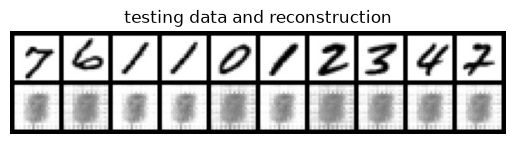

----- Epoch 2


 testing: 100%|██████████| 10/10 [00:00<00:00, 169.50batch/s]

losses training: 5.603411674499512, testing: 5.297992706298828


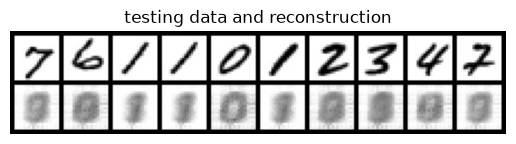

----- Epoch 3


 testing: 100%|██████████| 10/10 [00:00<00:00, 167.37batch/s]


losses training: 4.975088596343994, testing: 4.436563014984131


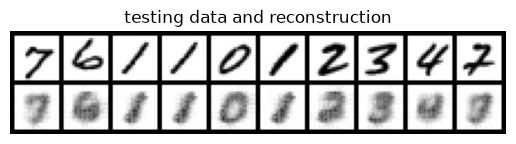

----- Epoch 4


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.83batch/s]


losses training: 4.273533344268799, testing: 3.787252902984619


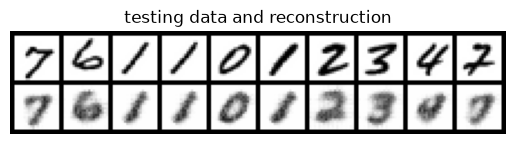

----- Epoch 5


 testing: 100%|██████████| 10/10 [00:00<00:00, 168.79batch/s]


losses training: 3.821737289428711, testing: 3.3839192390441895


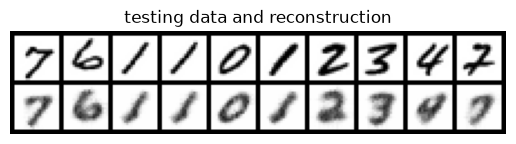

----- Epoch 6


 testing: 100%|██████████| 10/10 [00:00<00:00, 168.58batch/s]


losses training: 3.536172389984131, testing: 3.1882669925689697


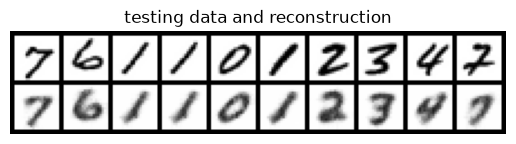

----- Epoch 7


 testing: 100%|██████████| 10/10 [00:00<00:00, 167.70batch/s]


losses training: 3.364034652709961, testing: 3.0252041816711426


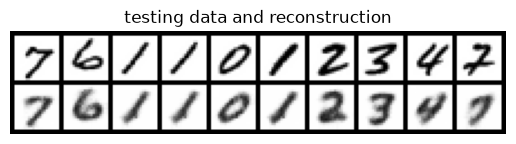

----- Epoch 8


 testing: 100%|██████████| 10/10 [00:00<00:00, 168.59batch/s]


losses training: 3.2241413593292236, testing: 2.8994739055633545


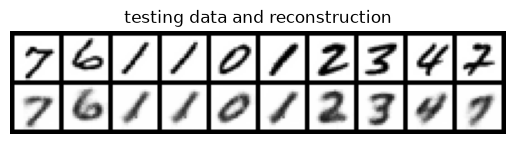

----- Epoch 9


 testing: 100%|██████████| 10/10 [00:00<00:00, 168.26batch/s]


losses training: 3.1129045486450195, testing: 2.786808729171753


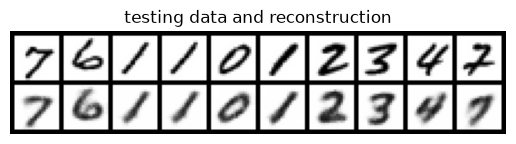

----- Epoch 10


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.32batch/s]


losses training: 3.018130302429199, testing: 2.70843243598938


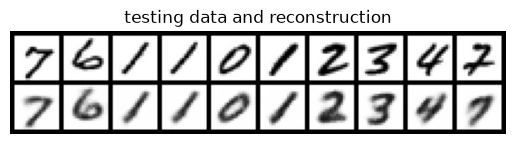

----- Epoch 11


 testing: 100%|██████████| 10/10 [00:00<00:00, 168.99batch/s]


losses training: 2.949451446533203, testing: 2.6565515995025635


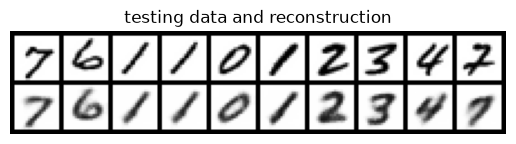

----- Epoch 12


 testing: 100%|██████████| 10/10 [00:00<00:00, 168.15batch/s]


losses training: 2.891805410385132, testing: 2.5755300521850586


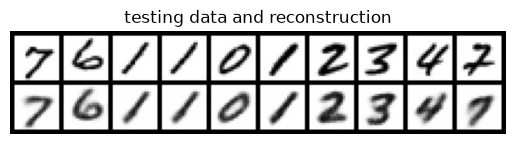

----- Epoch 13


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.17batch/s]


losses training: 2.835252523422241, testing: 2.5436627864837646


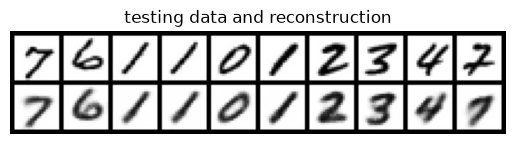

----- Epoch 14


 testing: 100%|██████████| 10/10 [00:00<00:00, 167.28batch/s]


losses training: 2.803609848022461, testing: 2.504798650741577


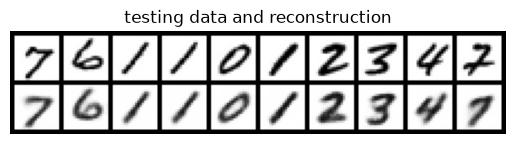

----- Epoch 15


 testing: 100%|██████████| 10/10 [00:00<00:00, 167.22batch/s]


losses training: 2.756094455718994, testing: 2.4710774421691895


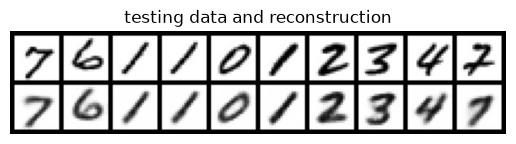

----- Epoch 16


 testing: 100%|██████████| 10/10 [00:00<00:00, 168.59batch/s]


losses training: 2.7307841777801514, testing: 2.4083092212677


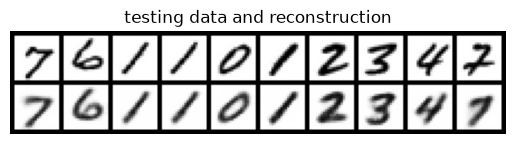

----- Epoch 17


 testing: 100%|██████████| 10/10 [00:00<00:00, 169.20batch/s]


losses training: 2.709533214569092, testing: 2.380413770675659


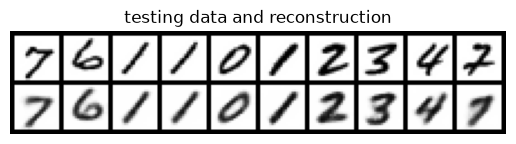

----- Epoch 18


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.81batch/s]

losses training: 2.6736817359924316, testing: 2.3657379150390625


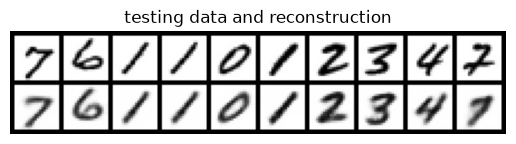

----- Epoch 19


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.16batch/s]


losses training: 2.6533703804016113, testing: 2.3400208950042725


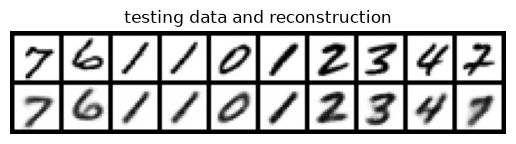

----- Epoch 20


 testing: 100%|██████████| 10/10 [00:00<00:00, 168.10batch/s]


losses training: 2.628877639770508, testing: 2.307466745376587


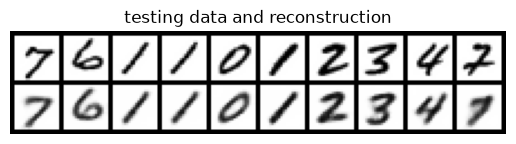

----- Epoch 21


 testing: 100%|██████████| 10/10 [00:00<00:00, 159.15batch/s]


losses training: 2.6091432571411133, testing: 2.2713446617126465


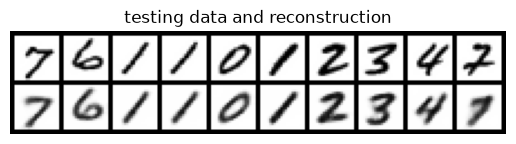

----- Epoch 22


 testing: 100%|██████████| 10/10 [00:00<00:00, 168.33batch/s]


losses training: 2.5891361236572266, testing: 2.2951998710632324


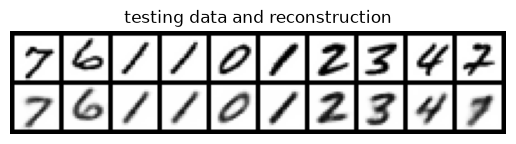

----- Epoch 23


 testing: 100%|██████████| 10/10 [00:00<00:00, 60.27batch/s]


losses training: 2.572850227355957, testing: 2.2682979106903076


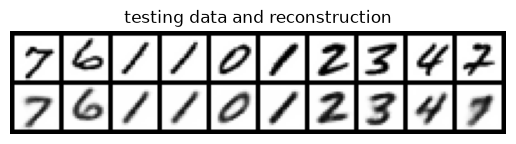

----- Epoch 24


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.59batch/s]


losses training: 2.5627281665802, testing: 2.2300186157226562


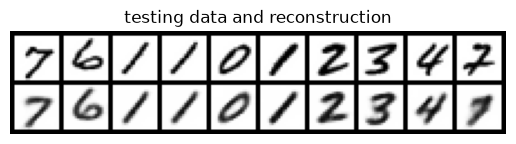

----- Epoch 25


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.85batch/s]


losses training: 2.541335344314575, testing: 2.2228639125823975


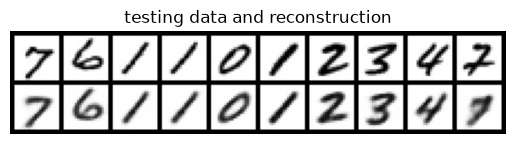

----- Epoch 26


 testing: 100%|██████████| 10/10 [00:00<00:00, 167.13batch/s]


losses training: 2.528944730758667, testing: 2.2160308361053467


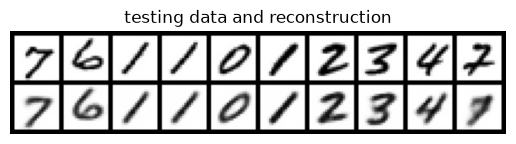

----- Epoch 27


 testing: 100%|██████████| 10/10 [00:00<00:00, 165.72batch/s]


losses training: 2.518801212310791, testing: 2.2030019760131836


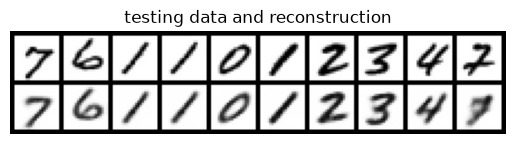

----- Epoch 28


 testing: 100%|██████████| 10/10 [00:00<00:00, 167.28batch/s]

losses training: 2.5061867237091064, testing: 2.186408758163452


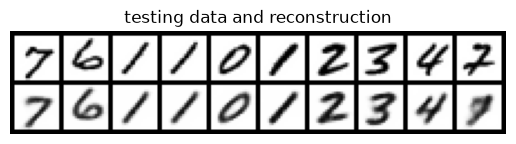

----- Epoch 29


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.55batch/s]


losses training: 2.495962381362915, testing: 2.1783359050750732


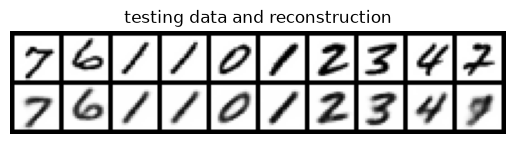

----- Epoch 30


 testing: 100%|██████████| 10/10 [00:00<00:00, 165.19batch/s]

losses training: 2.479607582092285, testing: 2.1699230670928955


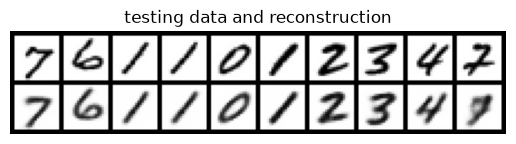

----- Epoch 31


 testing: 100%|██████████| 10/10 [00:00<00:00, 168.09batch/s]


losses training: 2.474583387374878, testing: 2.152055501937866


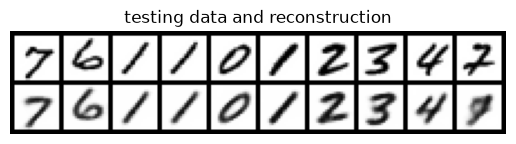

----- Epoch 32


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.10batch/s]


losses training: 2.464414596557617, testing: 2.1426501274108887


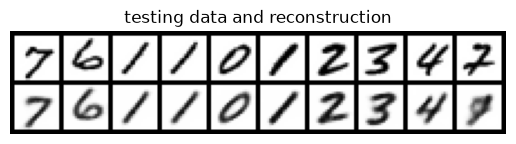

----- Epoch 33


 testing: 100%|██████████| 10/10 [00:00<00:00, 168.01batch/s]

losses training: 2.458052396774292, testing: 2.1470067501068115


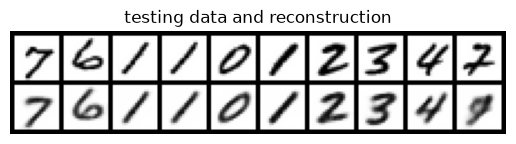

----- Epoch 34


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.44batch/s]


losses training: 2.4451136589050293, testing: 2.165759801864624


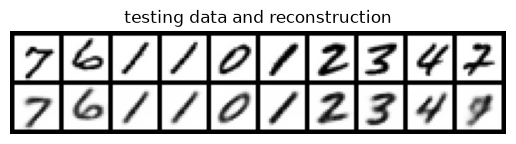

----- Epoch 35


 testing: 100%|██████████| 10/10 [00:00<00:00, 164.32batch/s]


losses training: 2.4362926483154297, testing: 2.124584913253784


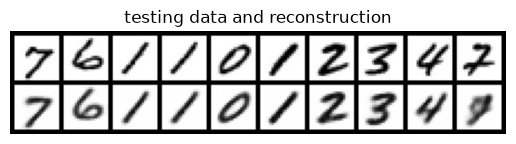

----- Epoch 36


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.79batch/s]


losses training: 2.4339234828948975, testing: 2.110090970993042


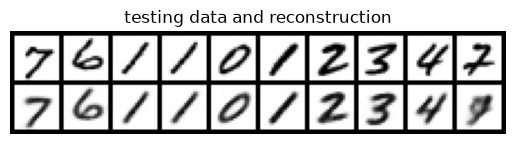

----- Epoch 37


 testing: 100%|██████████| 10/10 [00:00<00:00, 165.63batch/s]


losses training: 2.4272513389587402, testing: 2.123098373413086


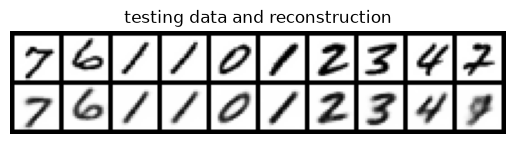

----- Epoch 38


 testing: 100%|██████████| 10/10 [00:00<00:00, 165.41batch/s]

losses training: 2.4135496616363525, testing: 2.1024277210235596


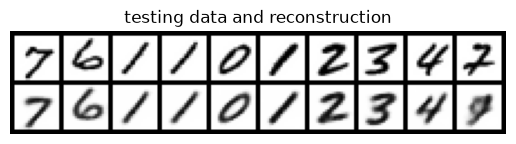

----- Epoch 39


 testing: 100%|██████████| 10/10 [00:00<00:00, 167.27batch/s]


losses training: 2.410400629043579, testing: 2.0973119735717773


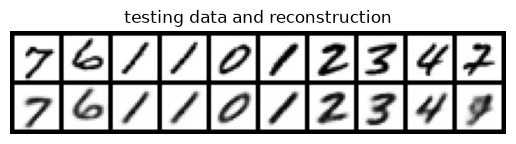

----- Epoch 40


 testing: 100%|██████████| 10/10 [00:00<00:00, 167.96batch/s]


losses training: 2.4040350914001465, testing: 2.132079839706421


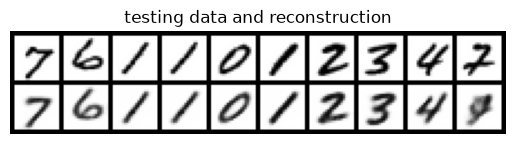

----- Epoch 41


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.52batch/s]


losses training: 2.3947439193725586, testing: 2.0812175273895264


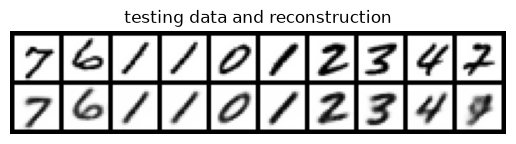

----- Epoch 42


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.84batch/s]


losses training: 2.3936972618103027, testing: 2.0623416900634766


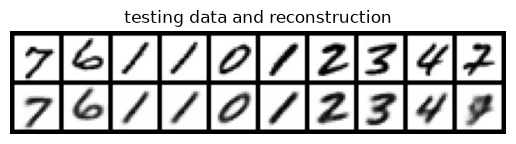

----- Epoch 43


 testing: 100%|██████████| 10/10 [00:00<00:00, 165.80batch/s]

losses training: 2.387899875640869, testing: 2.079322338104248


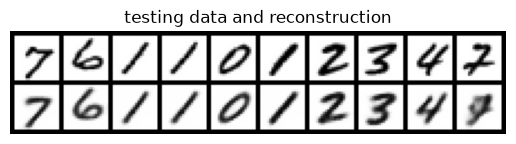

----- Epoch 44


 testing: 100%|██████████| 10/10 [00:00<00:00, 167.15batch/s]


losses training: 2.374924898147583, testing: 2.082252025604248


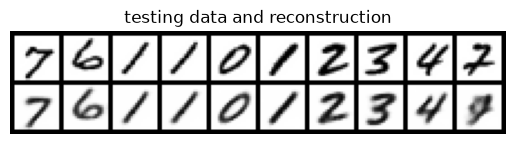

----- Epoch 45


 testing: 100%|██████████| 10/10 [00:00<00:00, 167.33batch/s]


losses training: 2.375232458114624, testing: 2.07261061668396


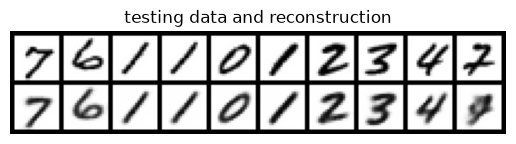

----- Epoch 46


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.85batch/s]


losses training: 2.3699088096618652, testing: 2.0610718727111816


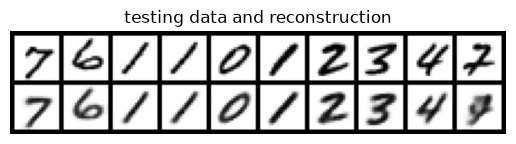

----- Epoch 47


 testing: 100%|██████████| 10/10 [00:00<00:00, 168.26batch/s]


losses training: 2.360349178314209, testing: 2.064613103866577


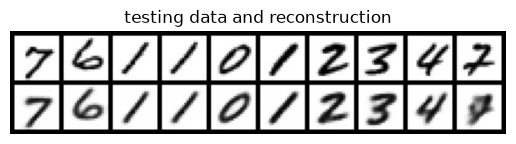

----- Epoch 48


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.35batch/s]

losses training: 2.3585526943206787, testing: 2.054112195968628


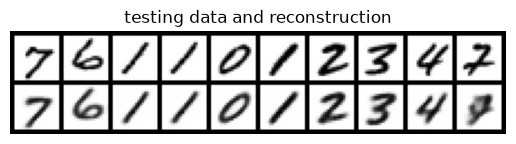

----- Epoch 49


 testing: 100%|██████████| 10/10 [00:00<00:00, 167.71batch/s]


losses training: 2.3541460037231445, testing: 2.090317487716675


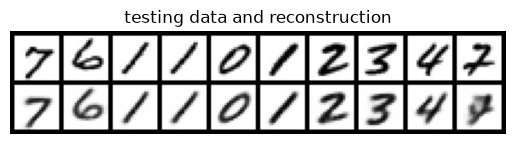

----- Epoch 50


 testing: 100%|██████████| 10/10 [00:00<00:00, 166.85batch/s]


losses training: 2.3519997596740723, testing: 2.054140567779541


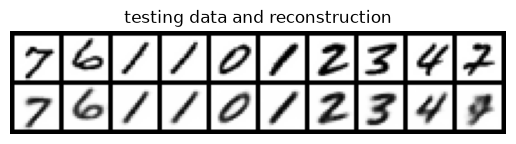

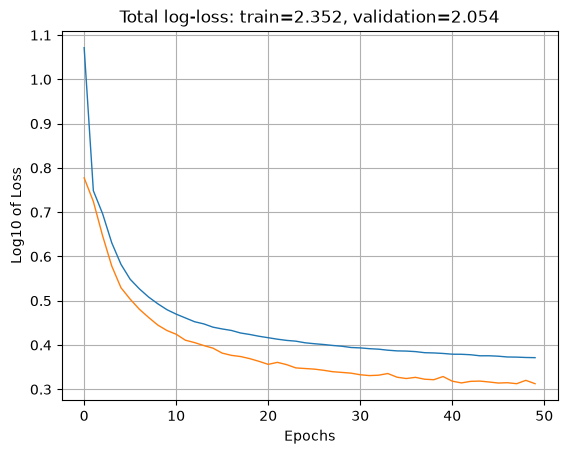

In [21]:
# start the training
losses = training_loop(model, train_dataloader, test_dataloader, nb_epoch=50)

# create the figure with a plot of the loss
plt.plot(np.log10(losses), label=['training','validation'], linestyle='solid', linewidth=1.0)
plt.title("Total log-loss: train={0:.3f}, validation={1:.3f}".format(losses[-1][0], losses[-1][1]))
plt.xlabel("Epochs"); plt.ylabel("Log10 of Loss")
plt.grid(True)
plt.show()

In [22]:
import pickle

torch.save(model.state_dict(), 'cvae_baseline.pth')

with open('results_baseline.pkl', 'wb') as f:
    pickle.dump({'losses': [[float(a), float(b)] for a, b in losses]}, f)

print("saved cvae_baseline.pth and results_baseline.pkl")

saved cvae_baseline.pth and results_baseline.pkl


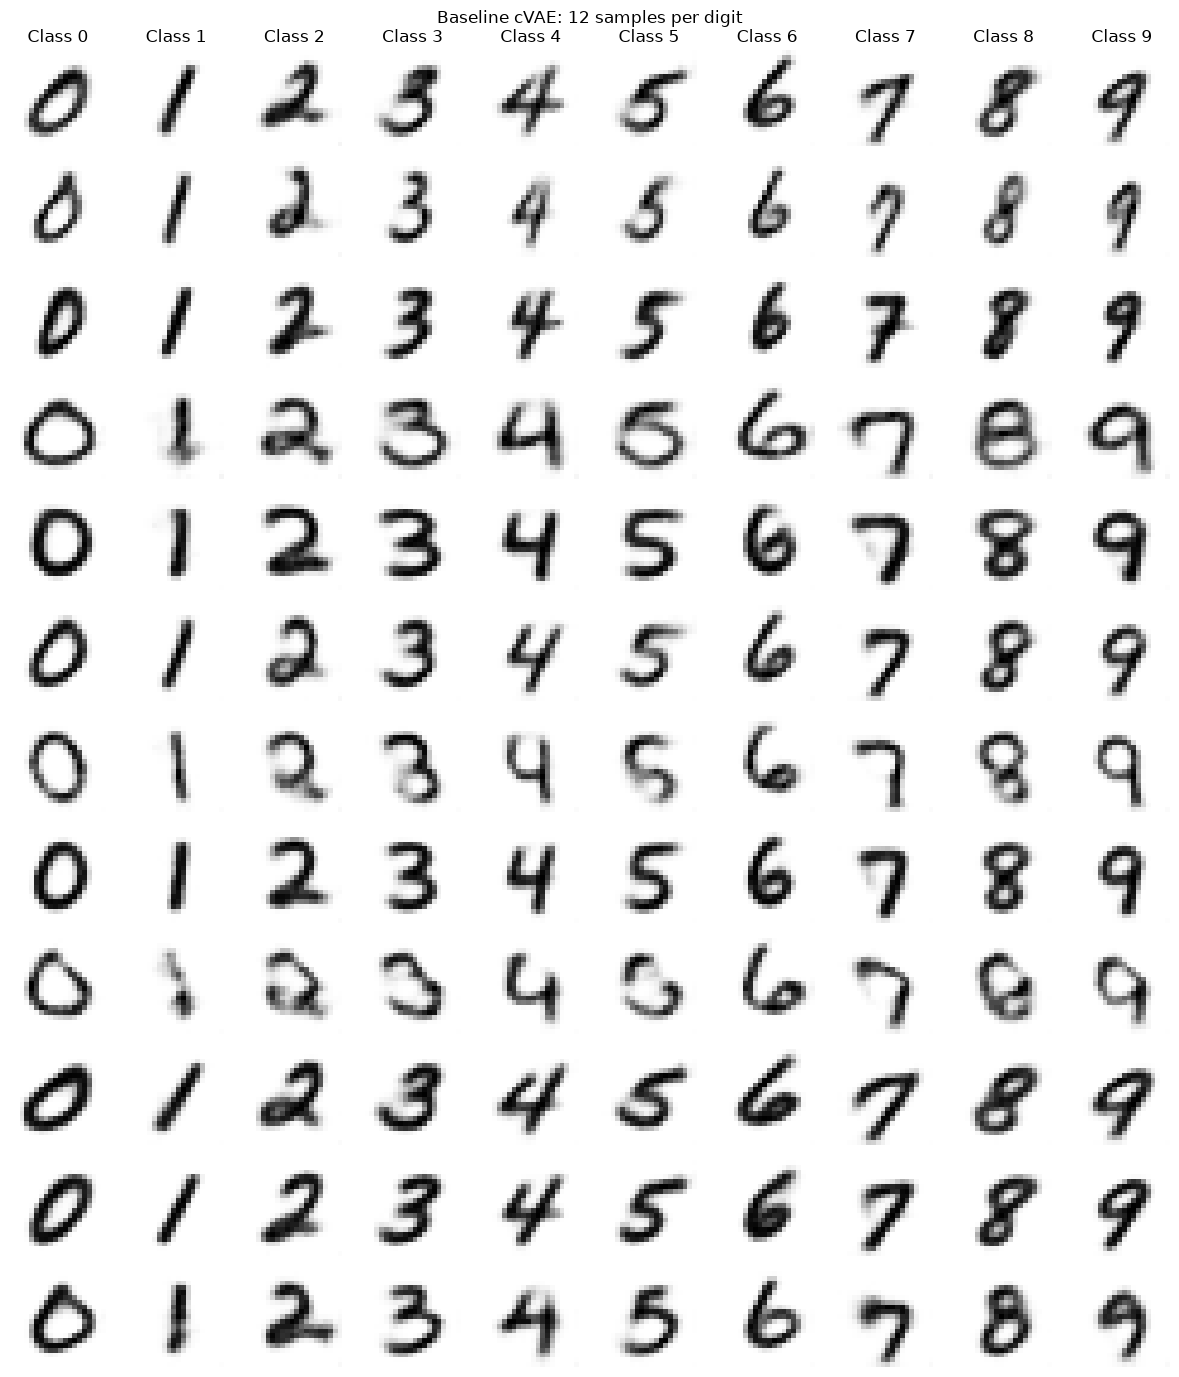

In [23]:
# number of samples per class (the brief asks for 12 per digit = 120 images)
num_samples = 12

model.eval()
with torch.no_grad():
    # Define all 10 conditions
    all_conditions = torch.eye(10).to(device)

    # sample different latent vector from prior
    torch.manual_seed(0)   # fixed so the same z is reused for the other model
    z_cond = torch.randn(num_samples, z_dim).to(device)

    all_xhat = []
    for cond in all_conditions:
        x_hat = model.decode(z_cond, cond.repeat(z_cond.shape[0],1)).cpu()
        all_xhat.append(x_hat)
    all_xhat = torch.stack(all_xhat)

# Plot the grid
fig, axes = plt.subplots(num_samples, 10, figsize=(12, 14))
for c in range(10):
    for i in range(num_samples):
        axes[i, c].imshow(all_xhat[c, i].squeeze(), cmap='gray')
        if i == 0:
            axes[i, c].set_title(f'Class {c}')
        axes[i, c].axis('off')
plt.suptitle('Baseline cVAE: 12 samples per digit')
plt.tight_layout()
plt.savefig('grid_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# save the latent vectors and samples so the same comparison can be reproduced
with open('samples_baseline.pkl', 'wb') as f:
    pickle.dump({'z': z_cond.cpu(), 'samples': all_xhat}, f)